# Build A Basic Chatbot With Langgraph(GRAPH API)


In [22]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [23]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [24]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model



In [27]:
llm=init_chat_model("groq:openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DD1C7547A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DD1C05C050>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [28]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [29]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

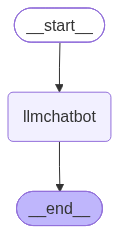

In [30]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [31]:
response=graph.invoke({"messages":"Hi"})

In [32]:
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='32ba8664-c7c0-4b0d-986e-d92fa605821d'),
  AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hi". We need to respond. There\'s no instruction to do anything else. It\'s a greeting. We should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 72, 'total_tokens': 119, 'completion_time': 0.048232599, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.003958316, 'prompt_tokens_details': None, 'queue_time': 0.264927841, 'total_time': 0.052190915}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_639a5351c8', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0aef7-f7c2-7532-99ba-b704a9f6a378-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 47, 'total_tokens':

In [33]:
response["messages"][-1].content

'Hello! How can I help you today?'

In [34]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm just a bunch of code, but I'm here and ready to help you. How can I assist you today?


# Chatbot With Tool

In [38]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.youtube.com/watch?v=Bops_dWhhVE',
   'title': 'LangGraph For Beginners: Agents Finally Explained',
   'content': "# LangGraph For Beginners: Agents Finally Explained\n## Channel: Thetips4you (verified)\n112K subscribers\n30 likes\n\n### Description\n2,105 views\nPosted: 2026-08-03\nLangGraph is a low-level orchestration framework for building long-running, stateful AI agents. In this beginner-friendly LangGraph full course for 2026, you will learn the mental model, build graphs with nodes and edges, add routing, create a tool-calling loop, and add short-term memory with a checkpointer. [...] [0:32] routing, two loops, memory and the production line behind this rel reliable\n[0:38] agents and we will build the core pieces in Python not just uh talk about them.\n[0:46] So what is a langraph? Lancraft is like a low-level orchestration framework for\n[0:53] buildin

In [39]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [41]:
tools=[tool,multiply]

In [42]:
llm_with_tool=llm.bind_tools(tools)

In [43]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.3', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DD1C7547A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DD1C05C050>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and 

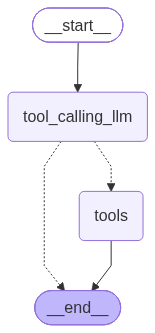

In [44]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [45]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [46]:
response['messages'][-1].content

'{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/google-ai-updates-august-2026", "title": "The latest AI news we announced in August 2026 - Google Blog", "content": "Google’s August 2026 updates focus on making artificial intelligence more practical through new hardware like the Pixel 11 series and cost-efficient models like Gemini 3.7 Flash. You can now use enhanced productivity tools in Gemini Live, access free AI plans for students, and leverage advanced video generation features. Explore these new capabilities today to see how they can streamline your daily tasks and creative projects. [...] See how WeatherNext 2 demonstrated a massive leap forward in predicting cyclones. In a _Nature_ paper, our researchers showed that WeatherNext 2 predicts cyclone track, intensity, and wind structure with state-of-the-art accuracy — delivering a decade of meteorological progress in o

In [48]:
response['messages']

[HumanMessage(content='What is the recent ai news', additional_kwargs={}, response_metadata={}, id='730db275-352d-4a1c-bab3-fd7f978d0149'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is the recent ai news". We need to provide recent AI news. Likely we need up-to-date info. We can use tavily_search to get current AI news. Let\'s search.', 'tool_calls': [{'id': 'fc_1004f809-d220-4aeb-a3f5-240ef8f97ba1', 'function': {'arguments': '{"query":"latest AI news 2026","search_depth":"basic","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 348, 'total_tokens': 431, 'completion_time': 0.0916654, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.019093865, 'prompt_tokens_details': None, 'queue_time': 0.240975092, 'total_time': 0.110759265}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4f7e7dc26e', 'service_tier': 'on_demand', 'fi

In [47]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_1004f809-d220-4aeb-a3f5-240ef8f97ba1)
 Call ID: fc_1004f809-d220-4aeb-a3f5-240ef8f97ba1
  Args:
    query: latest AI news 2026
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/google-ai-updates-august-2026", "title": "The latest AI news we announced in August 2026 - Google Blog", "content": "Google’s August 2026 updates focus on making artificial intelligence more practical through new hardware like the Pixel 11 series and cost-efficient models like Gemini 3.7 Flash. You can now use enhanced productivity tools in Gemi

In [49]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_2bfb1cb6-4689-4650-a84b-ef6533c63204)
 Call ID: fc_2bfb1cb6-4689-4650-a84b-ef6533c63204
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [50]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_1f75cff4-3632-42e6-8bd5-d35062553dab)
 Call ID: fc_1f75cff4-3632-42e6-8bd5-d35062553dab
  Args:
    query: recent AI news 2026
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://openai.com/index/model-misalignment-reporting-framework", "title": "Our framework for reporting model misalignment", "content": "Alignment\n   2026\n\n## Author\n\nOpenAI\n\n## Keep reading\n\nView all\n\nImage 1: Navier–Stokes solution — art card\n\nAn OpenAI model proposes a solution to the Navier–Stokes problem Research Sep 8, 2026\n\nImage 2: An alien mind

### ReAct Agent Architecture

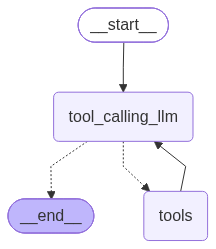

In [51]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [53]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_ec3dde15-a23a-43b6-b42b-132753f8281c)
 Call ID: fc_ec3dde15-a23a-43b6-b42b-132753f8281c
  Args:
    query: recent AI news 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.aljazeera.com/news/2026/9/17/what-are-the-biggest-ai-companies-and-how-much-are-they-worth", "title": "What are the biggest AI companies and how much are they worth?", "content": "This combination of pictures shows (from top left) Elon Musk of xA and Tesla, OpenAI CEO Sam Altman, DeepMind co-founder and chairman Demis Hassabis, Meta 

### Adding Memory In Agentic Graph

In [55]:
response=graph.invoke({"messages":"Hello my name is Shahab khan"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Shahab khan
================================== Ai Message ==================================

Hello Shahab! 👋 How can I help you today?


In [56]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I’m not able to see your personal details, so I don’t know your name. If you’d like to share it, I’ll be happy to use it in our conversation!


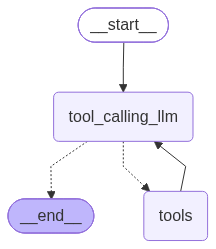

In [57]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [65]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Shahab khan"},config=config)

response['messages']


[HumanMessage(content='Hi my name is Shahab khan', additional_kwargs={}, response_metadata={}, id='3b23b7d5-1751-4025-a643-a69888c8b6f5'),
 AIMessage(content='Hello Shahab! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User: "Hi my name is Shahab khan". They are greeting. We should respond politely. No function needed.'}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 350, 'total_tokens': 398, 'completion_time': 0.052803033, 'completion_tokens_details': {'reasoning_tokens': 26}, 'prompt_time': 0.023729085, 'prompt_tokens_details': None, 'queue_time': 0.194092991, 'total_time': 0.076532118}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_228717f27c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0af0f-558e-7023-a033-5e961ea2d860-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 350, 'output_tokens': 48, 'total_tokens': 398, 'ou

In [66]:
response['messages'][-1].content

'Hi Shahab! 👋 I’m here and ready to help. What would you like to talk about or do today?'

In [67]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Shahab Khan.


In [68]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes—your name is Shahab Khan.  How can I help you today?


### Streaming

In [69]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [70]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

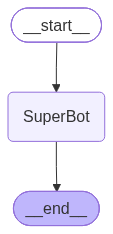

In [71]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [73]:

## Invocation

config = {"configurable": {"thread_id": "2"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='e3c6db8e-546b-4a08-a1a1-9a5e52808864'),
  AIMessage(content='Hello Krish! 👋 It’s great to meet a cricket fan. Which teams or players do you follow the most? And do you prefer Test matches, ODIs, or T20s? Let me know—I’d love to chat more about the sport!', additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Krish And I like cricket". They greet and mention interest. We should respond politely, maybe ask about cricket preferences. The user might want to talk about cricket. We should respond in a friendly way, maybe ask about favorite teams, players, etc. Also note the user is a person. No policy issues. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 82, 'total_tokens': 221, 'completion_time': 0.142530553, 'completion_tokens_details': {'reasoning_tokens': 77}, 'prompt_time': 0.003977189, 'prompt_to

### Streaming
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- values :give me the current/full state after each graph step.

- updates : give me what each node updated.

This is useful for:

- Showing an AI response progressively in a UI
- Displaying which agent/node is currently running
- Monitoring tool calls
- Debugging agents
- Building ChatGPT-like interfaces
- Observing multi-step agent execution

#### .stream() vs .astream()
- The main difference is synchronous vs asynchronous execution.
#### .stream()

- Use it in normal synchronous Python code.

#### .astream()

- Use it in asynchronous code.

### Difference Between value and update

````markdown
## The Easiest Way to Understand `values` vs `updates`

Imagine you're editing a document.

### Initial Document

`Hello`

Then you add:

`World`

The document becomes:

`Hello World`

Then you add:

`!`

The document becomes:

`Hello World!`

---

### `values`

With `values`, you get the **whole document/state each time**:

```text
Hello
Hello World
Hello World!
````

> **`values` = Give me the complete current state after each step.**

---

### `updates`

With `updates`, you get **only what was added or changed**:

```text
World
!
```

> **`updates` = Give me only the changes produced at each step.**

---

### Fundamental Difference

| Stream Mode | What You Receive         |
| ----------- | ------------------------ |
| `values`    | Complete current state   |
| `updates`   | Only the changes/updates |

### Easy Memory Trick

```text
values  → Whole state
updates → Changes only
```

**That's the fundamental difference.**

```
```


In [75]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Shahab And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hi Shahab! It’s awesome to hear you’re into cricket. Which team or player do you follow most, or do you enjoy playing the game yourself?', additional_kwargs={'reasoning_content': 'User says: "Hi,My name is Shahab And I like cricket". We need to respond. They mention name and interest. We can respond politely. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 139, 'total_tokens': 217, 'completion_time': 0.099483339, 'completion_tokens_details': {'reasoning_tokens': 37}, 'prompt_time': 0.007861317, 'prompt_tokens_details': None, 'queue_time': 0.334895389, 'total_time': 0.107344656}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_565badff47', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0af15-4018-7822-b700-4f5398593355-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 139, 'output_tokens':

In [81]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Shahab And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='f7e539a2-950a-443a-a483-a4d8c9c25a88'), AIMessage(content='Hey Krish! 👋🏼 Great to meet a fellow cricket fan. How do you like to follow the game? Are you into the IPL, Test matches, or perhaps the upcoming World Cup? If you’ve got a favorite team or player, let me know—I’d love to chat about it!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is Krish And I like cricket". We should greet, confirm. Maybe ask about cricket. Provide some cricket facts. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 82, 'total_tokens': 193, 'completion_time': 0.115387105, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.004530263, 'prompt_tokens_details': None, 'queue_time': 0.24112901, 'total_time': 0.119917368}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': '

In [82]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Shahab And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Shahab! 👋🏼 It’s awesome to meet another cricket fan. What’s your favorite format—IPL, Test cricket, ODIs, or the World Cup? And do you have a team or player you’re rooting for right now? Let’s dive into the game!', additional_kwargs={'reasoning_content': 'User repeats same greeting. They want to chat about cricket. We should respond friendly, ask about preferences.'}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 394, 'total_tokens': 482, 'completion_time': 0.093663404, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.020673655, 'prompt_tokens_details': None, 'queue_time': 0.302720816, 'total_time': 0.114337059}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e189667b30', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0af15-c389-7472-839c-b11125bcbbb6-0', tool_calls=[], invalid_tool_calls=[], usage_meta

In [83]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='f7e539a2-950a-443a-a483-a4d8c9c25a88'), AIMessage(content='Hey Krish! 👋🏼 Great to meet a fellow cricket fan. How do you like to follow the game? Are you into the IPL, Test matches, or perhaps the upcoming World Cup? If you’ve got a favorite team or player, let me know—I’d love to chat about it!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is Krish And I like cricket". We should greet, confirm. Maybe ask about cricket. Provide some cricket facts. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 82, 'total_tokens': 193, 'completion_time': 0.115387105, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.004530263, 'prompt_tokens_details': None, 'queue_time': 0.24112901, 'total_time': 0.119917368}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': '

In [84]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Shahab and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Shahab and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0af16-171f-7fb1-85ec-b25fd4557ada', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Shahab and I like to play cricket', additional_kwargs={}, response_metadata={}, id='a7357977-1a61-4751-affb-74962960e8ba')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a0af16-1741-7a91-91a6-73f4873fe9ff', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:7b67596c-ac05-40f7-2e43-0cd8859ab79b'}, 'parent_ids': ['01a0af16-171f-7fb1-85ec-b25fd4557ada']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages